In [1]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras import layers, models, backend as K

# Set the seed for reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

2025-08-15 17:40:51.989119: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-15 17:40:51.996995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755290452.006228  429690 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755290452.009143  429690 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755290452.016291  429690 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Path to the saved models
model_dir = "../../models/vae/"

# Load the encoder
# We pass the custom layer in the `custom_objects` dictionary
encoder = models.load_model(
    os.path.join(model_dir, "m1_encoder.keras"),
    custom_objects={"Sampling": Sampling}
)

# Load the decoder
decoder = models.load_model(os.path.join(model_dir, "m1_decoder.keras"))

print("Encoder and Decoder models loaded successfully!")
encoder.summary()
decoder.summary()

I0000 00:00:1755290453.248401  429690 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 977 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


Encoder and Decoder models loaded successfully!


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_86      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_117 (Conv2D) │ (None, 14, 14,    │        320 │ input_layer_86[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_117[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_118 (Conv2D) │ (None, 7, 7, 64)  │     18,496 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ conv2d_118[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_119 (Conv2D) │ (None, 7, 7, 128) │     73,856 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_43          │ (None, 6272)      │          0 │ conv2d_119[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_117 (Dense)   │ (None, 64)        │    401,472 │ flatten_43[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      1,040 │ dense_117[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      1,040 │ dense_117[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_43         │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 496,608 (1.89 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_87 (InputLayer)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 6272)           │       407,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_43 (Reshape)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_160            │ (None, 7, 7, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_126         │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_161            │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_127         │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_162            │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_163            │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,665 (2.48 MB)

 Trainable params: 649,281 (2.48 MB)

 Non-trainable params: 384 (1.50 KB)

### Building the M2 Classifier

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import LeakyReLU, BatchNormalization

def build_classifier(num_classes=10):
    """
    Builds a deeper, more robust convolutional classifier for MNIST.
    
    Args:
        num_classes (int): The number of output classes.
        
    Returns:
        A Keras Model for the classifier.
    """
    inputs = layers.Input(shape=(28, 28, 1))
    
    # Block 1
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x) # Added for stability
    x = layers.MaxPooling2D()(x)
    
    # Block 2
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x) # Added for stability
    x = layers.MaxPooling2D()(x)
    
    # Block 3 (New Layer)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x) # Added for stability
    
    # Fully Connected Head
    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.5)(x)
    
    # Extra Dense Layer (New Layer)
    x = layers.Dense(64)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.5)(x)
    
    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    classifier = models.Model(inputs, outputs, name="classifier_m2")
    return classifier

# Instantiate the new, deeper classifier
classifier = build_classifier()
classifier.summary()

/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "classifier_m2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 905,418 (3.45 MB)

 Trainable params: 904,970 (3.45 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
import tensorflow as tf
from tensorflow.keras import models, metrics
from tensorflow.keras.losses import SparseCategoricalCrossentropy, BinaryCrossentropy

class SemiSupervisedVAE(models.Model):
    def __init__(self, encoder, decoder, classifier, alpha=0.1, **kwargs):
        super(SemiSupervisedVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.classifier = classifier
        self.alpha = alpha  # Weight for the classification loss

        # Loss function instances
        self.bce_loss = BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
        self.scce_loss = SparseCategoricalCrossentropy(reduction=tf.keras.losses.Reduction.NONE)

        # Loss trackers
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.vae_loss_tracker = metrics.Mean(name="vae_loss")
        self.clf_loss_tracker = metrics.Mean(name="clf_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.vae_loss_tracker, self.clf_loss_tracker]

    def call(self, inputs):
        # This model is used for training, not direct inference
        return self.classifier(inputs)
        
    def _calculate_vae_loss(self, x):
        """Calculates the VAE loss (reconstruction + KL divergence) for a given input."""
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        
        recon_loss = tf.reduce_sum(self.bce_loss(x, reconstruction), axis=(1, 2))
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        
        return tf.reduce_mean(recon_loss + kl_loss)

    def _calculate_labeled_loss(self, x, y):
        """Calculates the total loss for a batch of labeled data."""
        # VAE loss for labeled data
        vae_loss = self._calculate_vae_loss(x)
        
        # Supervised classification loss
        y_pred = self.classifier(x)
        clf_loss = tf.reduce_mean(self.scce_loss(y, y_pred))
        
        # Weighted combination of both losses
        # The paper scales the classification loss by a factor that includes the batch size.
        scaled_clf_loss = self.alpha * tf.cast(tf.shape(x)[0], tf.float32) * clf_loss
        
        return vae_loss + scaled_clf_loss

    def _calculate_unlabeled_loss(self, x):
        """Calculates the total loss for a batch of unlabeled data."""
        # VAE loss for unlabeled data
        vae_loss = self._calculate_vae_loss(x)
        
        # Unsupervised classification loss
        y_pred = self.classifier(x)
        
        # Sum over all possible labels y, weighted by the classifier's own prediction q(y|x)
        unlabeled_clf_loss = 0
        for i in range(10):  # For each possible class
            y_i = tf.fill((tf.shape(x)[0], 1), float(i))
            unlabeled_clf_loss += y_pred[:, i] * self.scce_loss(y_i, y_pred)
        
        # Entropy of the classifier's prediction H(q(y|x)) to encourage confident predictions
        entropy = -tf.reduce_sum(y_pred * tf.math.log(y_pred + 1e-10), axis=1)
        
        return vae_loss + tf.reduce_mean(unlabeled_clf_loss - entropy)

    def train_step(self, data):
        labeled_data, unlabeled_data = data
        x_labeled, y_labeled = labeled_data
        x_unlabeled = unlabeled_data[0] # Unpack from tuple

        with tf.GradientTape() as tape:
            # Calculate losses using the helper methods
            labeled_loss = self._calculate_labeled_loss(x_labeled, y_labeled)
            unlabeled_loss = self._calculate_unlabeled_loss(x_unlabeled)
            
            # Combine for the final loss
            total_loss = labeled_loss + unlabeled_loss
            
        # Compute and apply gradients
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update trackers (using the raw loss components for clarity)
        self.total_loss_tracker.update_state(total_loss)
        self.vae_loss_tracker.update_state(self._calculate_vae_loss(x_labeled) + self._calculate_vae_loss(x_unlabeled))
        self.clf_loss_tracker.update_state(tf.reduce_mean(self.scce_loss(y_labeled, self.classifier(x_labeled))))

        return {m.name: m.result() for m in self.metrics}

In [6]:
import tensorflow as tf
import numpy as np

# Load and preprocess the full MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train.astype("float32") / 255, -1)
x_test = np.expand_dims(x_test.astype("float32") / 255, -1)

# Set the number of labeled samples
num_labeled = 1000

# Create the labeled dataset
x_labeled = x_train[:num_labeled]
y_labeled = y_train[:num_labeled]

# Create the unlabeled dataset (the rest of the training data)
x_unlabeled = x_train[num_labeled:]
# We don't use y_unlabeled during training, so we can ignore it

print(f"Shape of labeled images: {x_labeled.shape}")
print(f"Shape of labeled labels: {y_labeled.shape}")
print(f"Shape of unlabeled images: {x_unlabeled.shape}")

Shape of labeled images: (1000, 28, 28, 1)
Shape of labeled labels: (1000,)
Shape of unlabeled images: (59000, 28, 28, 1)


In [7]:
def data_generator(x_labeled, y_labeled, x_unlabeled, batch_size):
    """Yields batches of labeled and unlabeled data."""
    labeled_dataset = tf.data.Dataset.from_tensor_slices((x_labeled, y_labeled))
    labeled_dataset = labeled_dataset.shuffle(buffer_size=len(x_labeled)).repeat().batch(batch_size)
    
    unlabeled_dataset = tf.data.Dataset.from_tensor_slices((x_unlabeled, tf.zeros(len(x_unlabeled))))
    unlabeled_dataset = unlabeled_dataset.shuffle(buffer_size=len(x_unlabeled)).repeat().batch(batch_size)
    
    labeled_iterator = iter(labeled_dataset)
    unlabeled_iterator = iter(unlabeled_dataset)
    
    while True:
        yield (next(labeled_iterator), next(unlabeled_iterator))

In [ ]:
# --- Instantiate and Compile the Combined Model ---
#CORRER DE NUEVO CON EL ALPHA EN 1
ss_vae = SemiSupervisedVAE(encoder, decoder, classifier, alpha=1)#0.5 * len(x_train))
ss_vae.compile(optimizer=tf.keras.optimizers.Adam())


# --- Create the data generator ---
batch_size = 100
# Calculate steps per epoch to cover the unlabeled dataset once
steps_per_epoch = len(x_unlabeled) // batch_size
train_gen = data_generator(x_labeled, y_labeled, x_unlabeled, batch_size)

# --- Train the model ---
print("\nStarting semi-supervised training...")
history = ss_vae.fit(
    train_gen,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    verbose=1
)


Starting semi-supervised training...
Epoch 1/20


I0000 00:00:1755290479.541447  429887 cuda_dnn.cc:529] Loaded cuDNN version 90701


590/590 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - clf_loss: 0.2291 - total_loss: 780557.0625 - vae_loss: 184.3801
Epoch 2/20
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - clf_loss: 5.3228e-05 - total_loss: 341.4154 - vae_loss: 180.0025
Epoch 3/20
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - clf_loss: 1.5918e-05 - total_loss: 227.1159 - vae_loss: 178.7540
Epoch 4/20
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - clf_loss: 7.1708e-06 - total_loss: 199.5486 - vae_loss: 177.5320
Epoch 5/20
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - clf_loss: 3.8651e-06 - total_loss: 188.7543 - vae_loss: 176.7195
Epoch 6/20
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - clf_loss: 2.2857e-06 - total_loss: 183.2261 - vae_loss: 175.9431
Epoch 7/20
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - clf_loss: 1.4390e-06 - total_loss: 180.0328 - vae_loss: 175.3026
Epoch 8/20
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - clf_loss: 9.3504e-07 - total_loss: 178.3380 - vae_loss: 175.1147
Epoch 9/20
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/ste

In [9]:
# --- Evaluate the classifier's performance ---
print("\nEvaluating the classifier on the test set...")

# COMPILE the classifier before evaluating it
classifier.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# Now, evaluation will work
classifier_loss, classifier_accuracy = classifier.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {classifier_accuracy * 100:.2f}%")


Evaluating the classifier on the test set...


2025-08-15 17:44:59.071456: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Test Accuracy: 93.96%


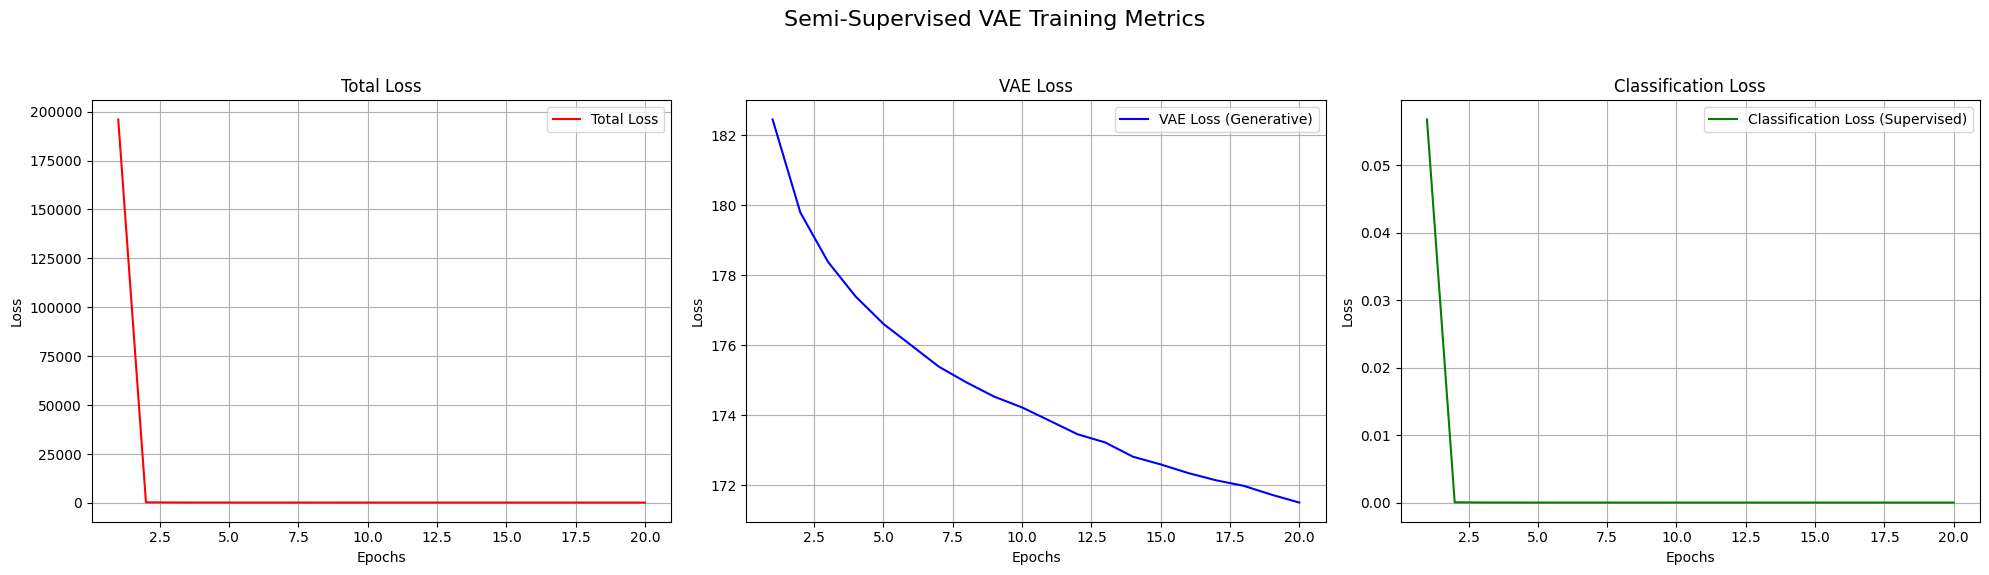

In [10]:
import matplotlib.pyplot as plt

def plot_training_metrics_subplots(history):
    """
    Plots the total, VAE, and classification losses in separate side-by-side subplots.
    """
    # Extract the loss values from the history object
    total_loss = history.history['total_loss']
    vae_loss = history.history['vae_loss']
    clf_loss = history.history['clf_loss']
    epochs = range(1, len(total_loss) + 1)
    
    # Create a figure with 3 subplots in a single row
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Semi-Supervised VAE Training Metrics', fontsize=16)

    # Plot Total Loss
    ax1.plot(epochs, total_loss, 'r-', label='Total Loss')
    ax1.set_title('Total Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot VAE Loss
    ax2.plot(epochs, vae_loss, 'b-', label='VAE Loss (Generative)')
    ax2.set_title('VAE Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    # Plot Classification Loss
    ax3.plot(epochs, clf_loss, 'g-', label='Classification Loss (Supervised)')
    ax3.set_title('Classification Loss')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('Loss')
    ax3.legend()
    ax3.grid(True)
    
    # Adjust layout to prevent titles from overlapping
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Call the function with the history from your model training
plot_training_metrics_subplots(history)

In [11]:
from sklearn.manifold import TSNE
import numpy as np

# We'll use a subset of the test data for efficient plotting
num_samples_to_plot = 5000
indices = np.random.choice(range(len(x_test)), num_samples_to_plot)
test_images_subset = x_test[indices]
test_labels_subset = y_test[indices]

print("Generating latent vectors from the final trained encoder...")
# The encoder's weights were updated during the ss_vae training
z_mean, _, _ = encoder.predict(test_images_subset, verbose=0)

print("Running t-SNE... (This may take a moment)")
tsne = TSNE(n_components=2, perplexity=30.0, max_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(z_mean)

print("t-SNE complete.")

Generating latent vectors from the final trained encoder...


2025-08-15 17:45:12.987723: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Running t-SNE... (This may take a moment)
t-SNE complete.


/tmp/ipykernel_429690/3949122535.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("jet", 10),


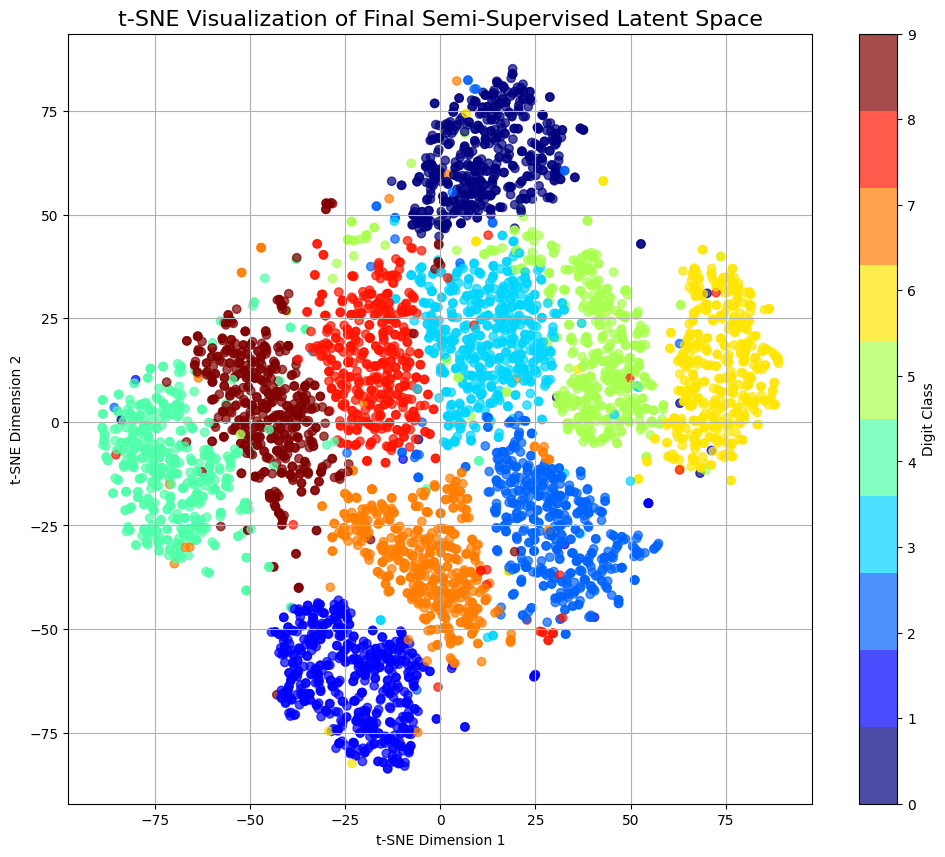

In [12]:
import matplotlib.pyplot as plt

def plot_tsne_scatter(tsne_results, labels):
    """Creates a colored scatter plot of t-SNE results."""
    plt.figure(figsize=(12, 10))
    
    scatter = plt.scatter(
        tsne_results[:, 0], 
        tsne_results[:, 1], 
        c=labels, 
        cmap=plt.cm.get_cmap("jet", 10),
        alpha=0.7
    )
    
    plt.title("t-SNE Visualization of Final Semi-Supervised Latent Space", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label("Digit Class")
    
    plt.grid(True)
    plt.show()

# Call the plotting function
plot_tsne_scatter(tsne_results, test_labels_subset)

/tmp/ipykernel_429690/1327176654.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap=plt.cm.get_cmap("jet", 10), alpha=0.1)


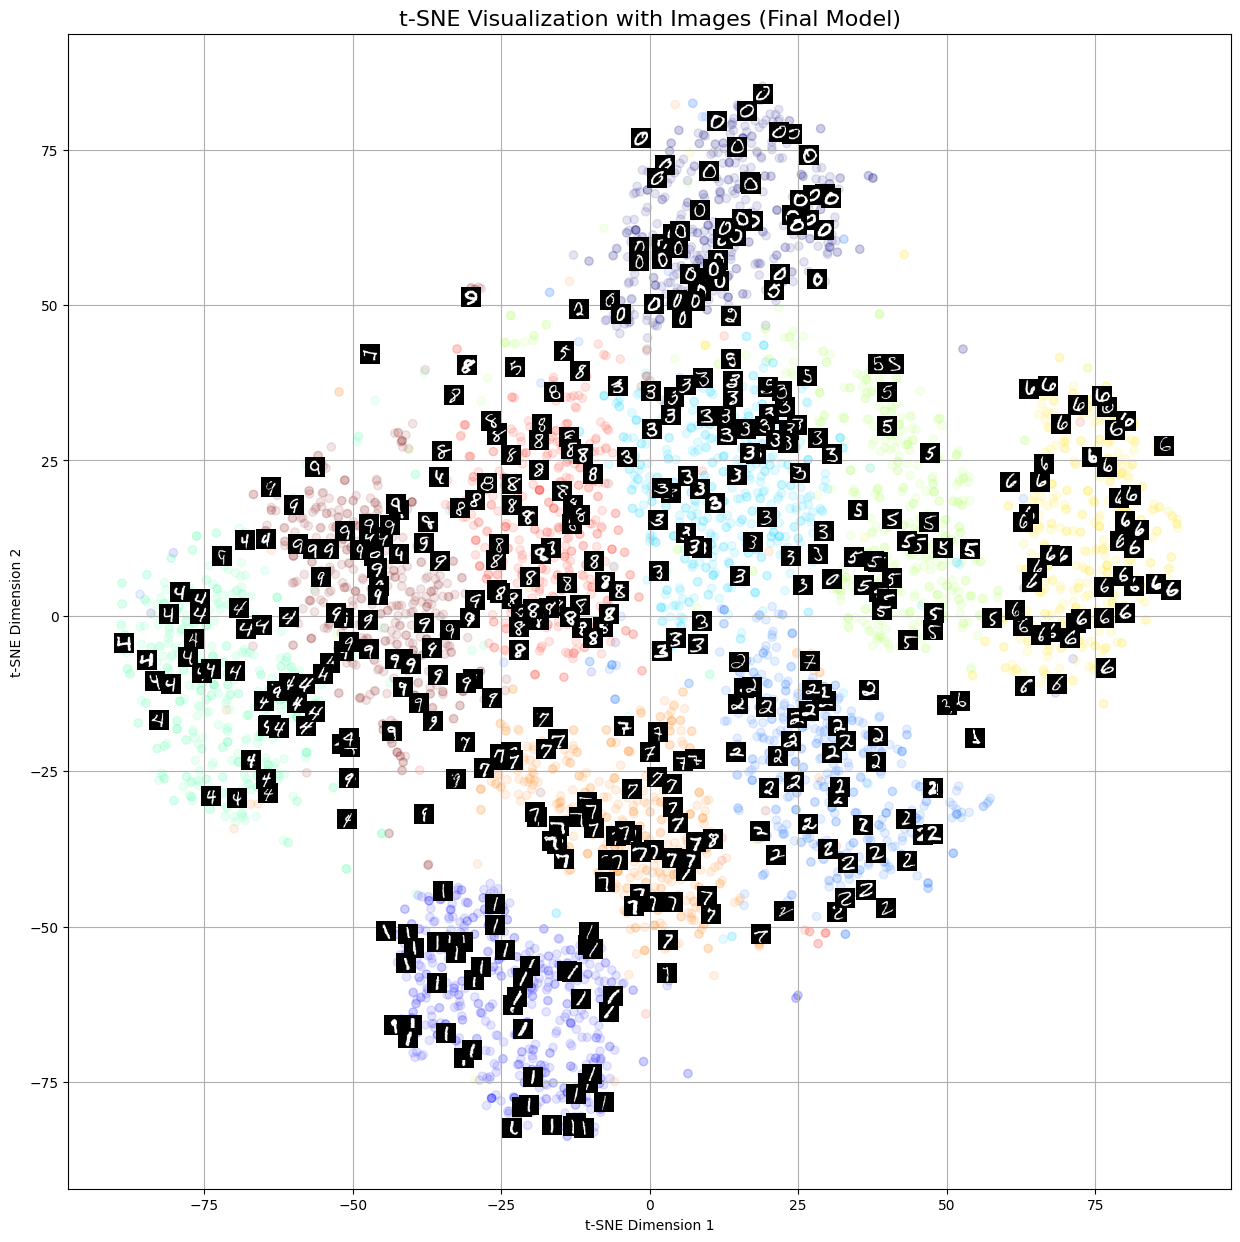

In [13]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def plot_tsne_images(tsne_results, images, labels, zoom=0.5):
    """Creates a t-SNE plot with original images instead of dots."""
    
    fig, ax = plt.subplots(figsize=(15, 15))
    ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap=plt.cm.get_cmap("jet", 10), alpha=0.1)
    
    num_images_to_show = 500
    indices_to_show = np.random.choice(range(len(images)), num_images_to_show)

    for i in indices_to_show:
        x, y = tsne_results[i, :]
        img = images[i].reshape(28, 28)
        im = OffsetImage(img, cmap='gray', zoom=zoom)
        ab = AnnotationBbox(im, (x, y), frameon=False, pad=0.0)
        ax.add_artist(ab)
        
    ax.set_title("t-SNE Visualization with Images (Final Model)", fontsize=16)
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.grid(True)
    plt.show()

# Call the plotting function
plot_tsne_images(tsne_results, test_images_subset, test_labels_subset)

Generating archetypal image for each class...


2025-08-15 17:45:37.822663: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


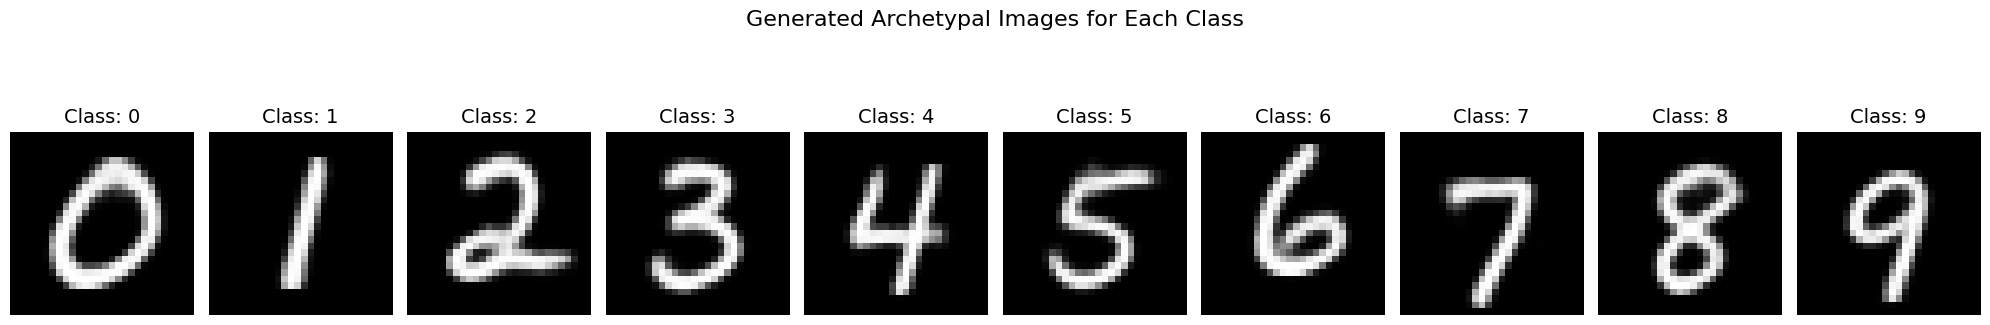

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Number of classes
num_classes = 10
# A list to store the generated archetypal images
generated_images = []

print("Generating archetypal image for each class...")

# Loop through each class from 0 to 9
for i in range(num_classes):
    # Find all test images belonging to the current class
    class_images = x_test[y_test == i]
    
    # Get the latent representations (z_mean) for these images from the encoder
    z_mean, _, _ = encoder.predict(class_images, verbose=0)
    
    # Calculate the average latent vector for the class
    average_z = np.mean(z_mean, axis=0)
    
    # The decoder expects a batch, so we reshape the average vector
    archetype_z = np.expand_dims(average_z, axis=0)
    
    # Decode the archetypal latent vector to generate an image
    reconstructed_image = decoder.predict(archetype_z, verbose=0)
    
    # Add the generated image to our list (squeezing out the batch and channel dims)
    generated_images.append(np.squeeze(reconstructed_image))

# --- Plotting the results ---
fig, axes = plt.subplots(1, num_classes, figsize=(20, 4))
fig.suptitle("Generated Archetypal Images for Each Class", fontsize=16)

for i, img in enumerate(generated_images):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Class: {i}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generating images with temperature = 1.0...


2025-08-15 17:45:42.860512: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


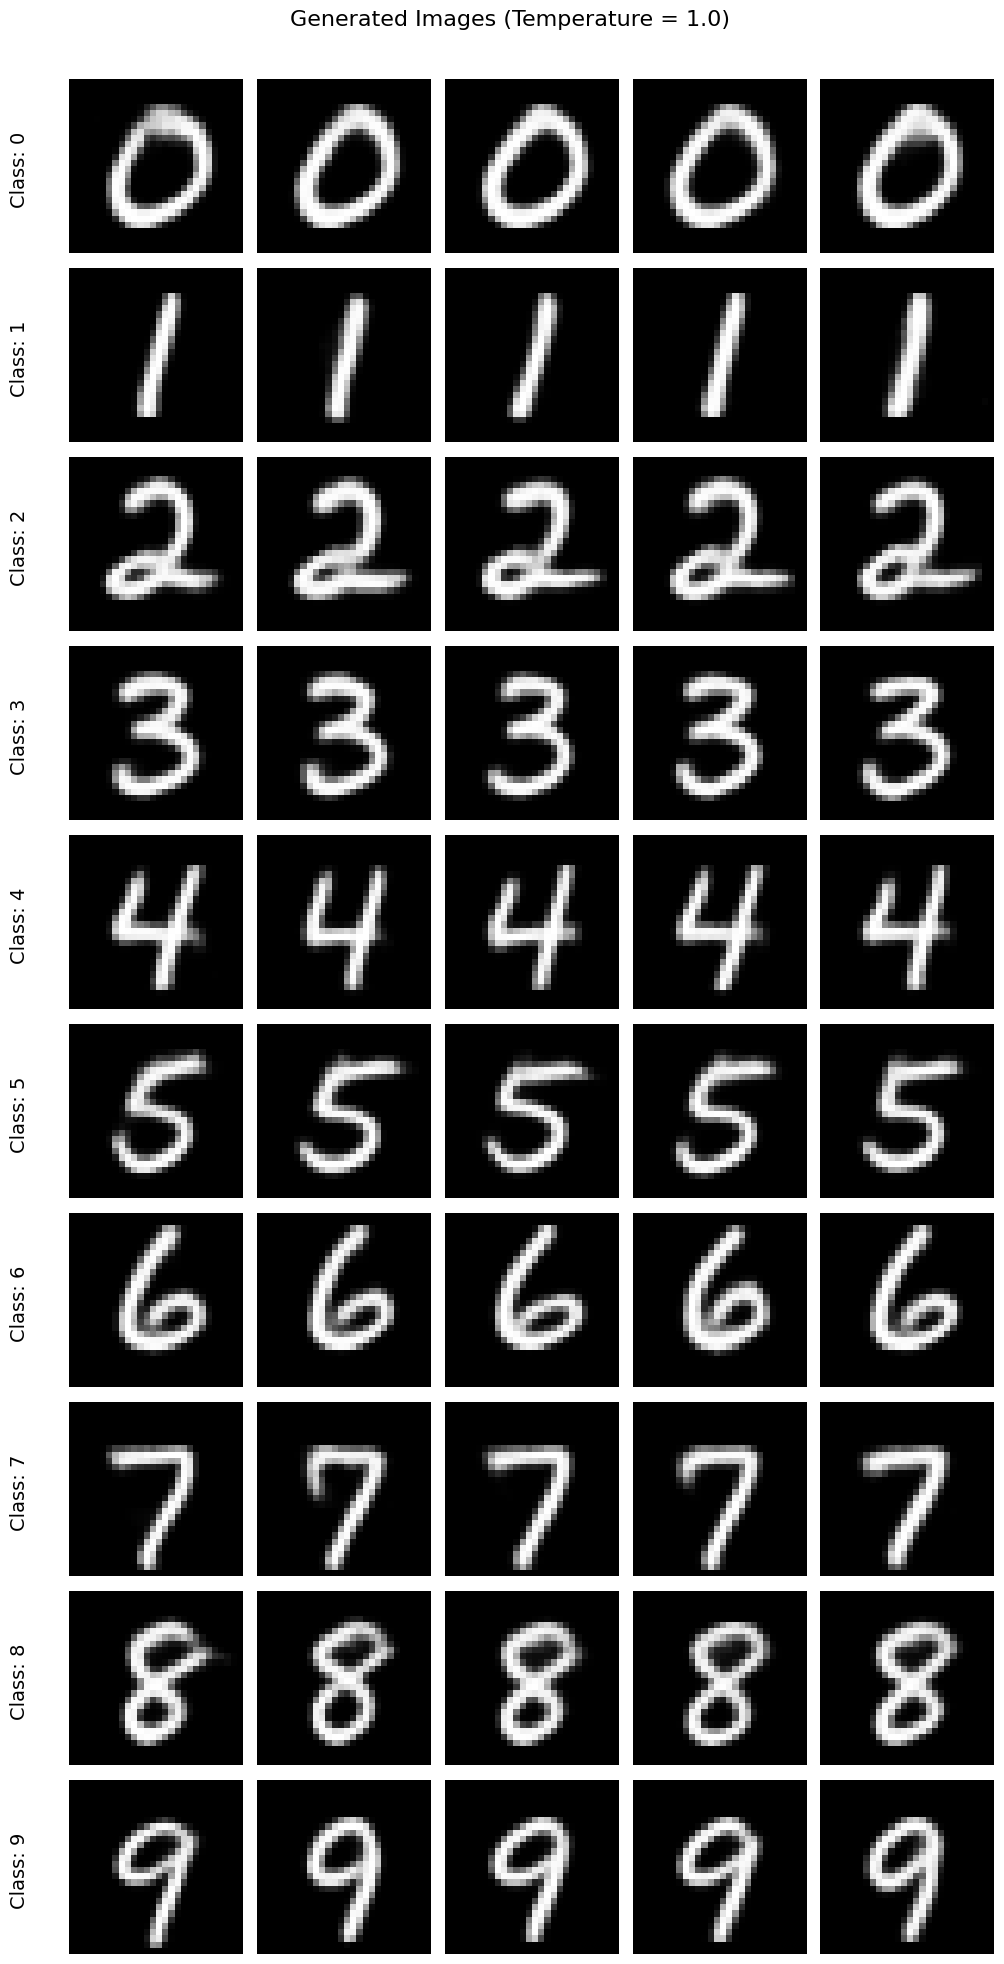

Generating images with temperature = 1.5...


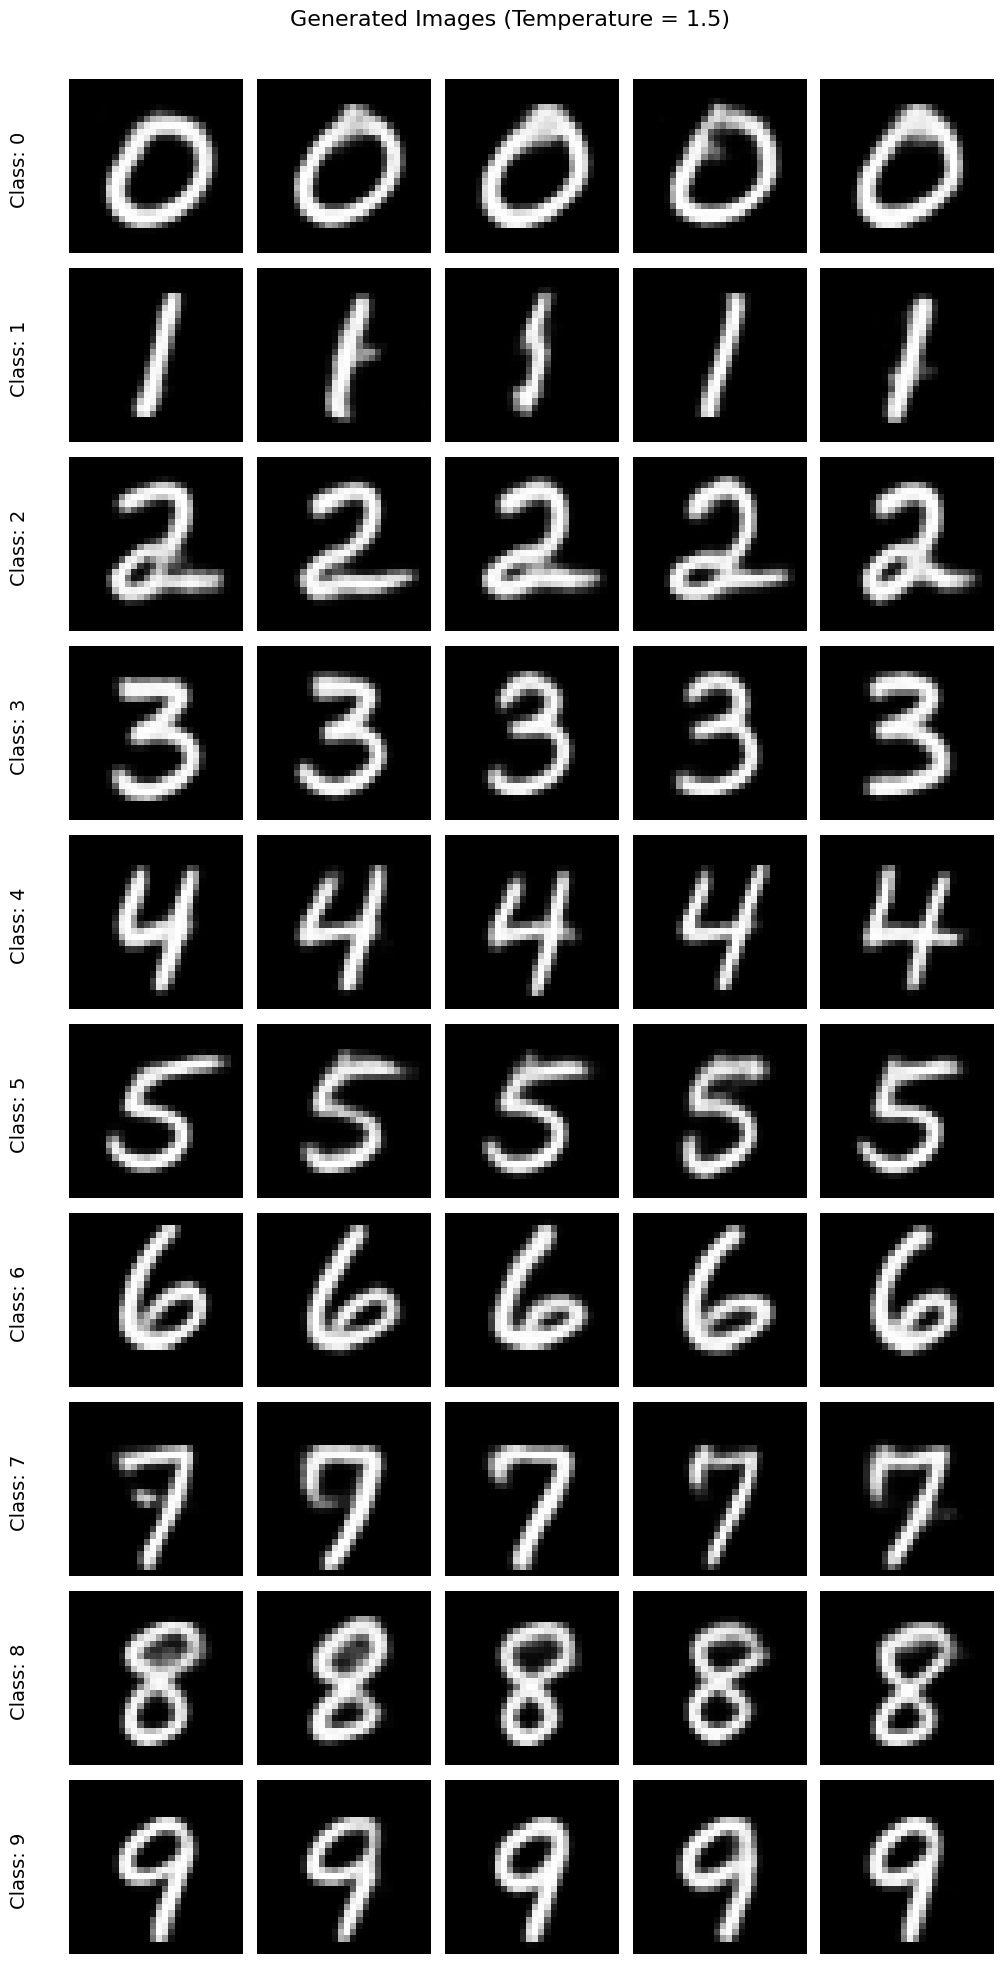

Generating images with temperature = 2.0...


2025-08-15 17:45:48.085640: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


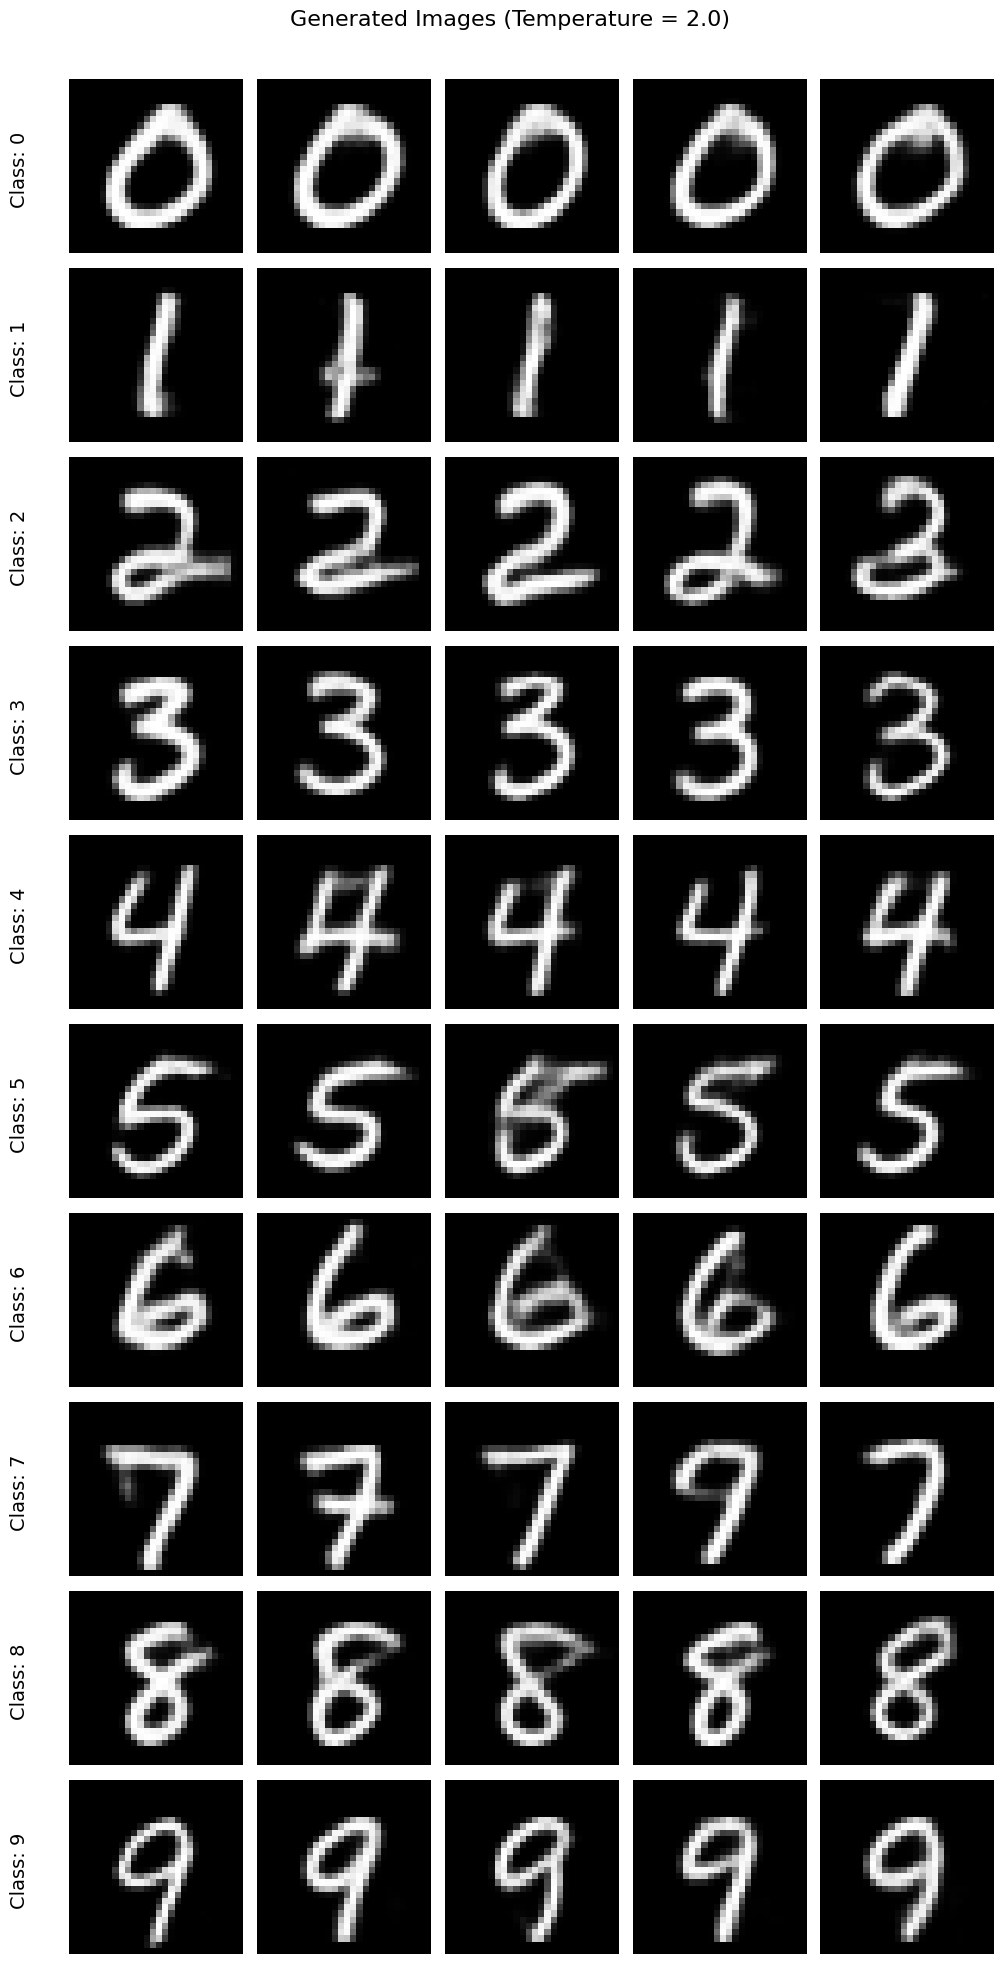

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def generate_and_plot_class_images(temperature=1.0):
    """
    Generates and plots images with a controllable diversity factor (temperature).
    """
    num_classes = 10
    samples_per_class = 5
    generated_images_dict = {i: [] for i in range(num_classes)}

    print(f"Generating images with temperature = {temperature}...")

    for i in range(num_classes):
        class_images = x_test[y_test == i]
        z_mean, z_log_var, _ = encoder.predict(class_images, verbose=0)
        
        class_z_mean = np.mean(z_mean, axis=0)
        class_z_log_var = np.mean(z_log_var, axis=0)
        
        for _ in range(samples_per_class):
            latent_dim = class_z_mean.shape[0]
            epsilon = tf.random.normal(shape=(1, latent_dim))
            
            # --- THIS IS THE KEY CHANGE ---
            # We multiply the standard deviation by the temperature
            standard_deviation = tf.exp(0.5 * class_z_log_var)
            z_sample = class_z_mean + temperature * standard_deviation * epsilon
            
            reconstructed_image = decoder.predict(z_sample, verbose=0)
            generated_images_dict[i].append(np.squeeze(reconstructed_image))

    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(10, 20))
    fig.suptitle(f"Generated Images (Temperature = {temperature})", fontsize=16)

    for i in range(num_classes):
        for j in range(samples_per_class):
            axes[i, j].imshow(generated_images_dict[i][j], cmap='gray')
            axes[i, j].axis('off')
        axes[i, 0].text(-10, 14, f'Class: {i}', verticalalignment='center', rotation='vertical', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# --- Experiment with different temperature values ---

# Original behavior (less diversity)
generate_and_plot_class_images(temperature=1.0)

# Higher diversity
generate_and_plot_class_images(temperature=1.5)

# Even higher diversity (may produce less realistic images)
generate_and_plot_class_images(temperature=2.0)

Generating images with temperature = 10.0...


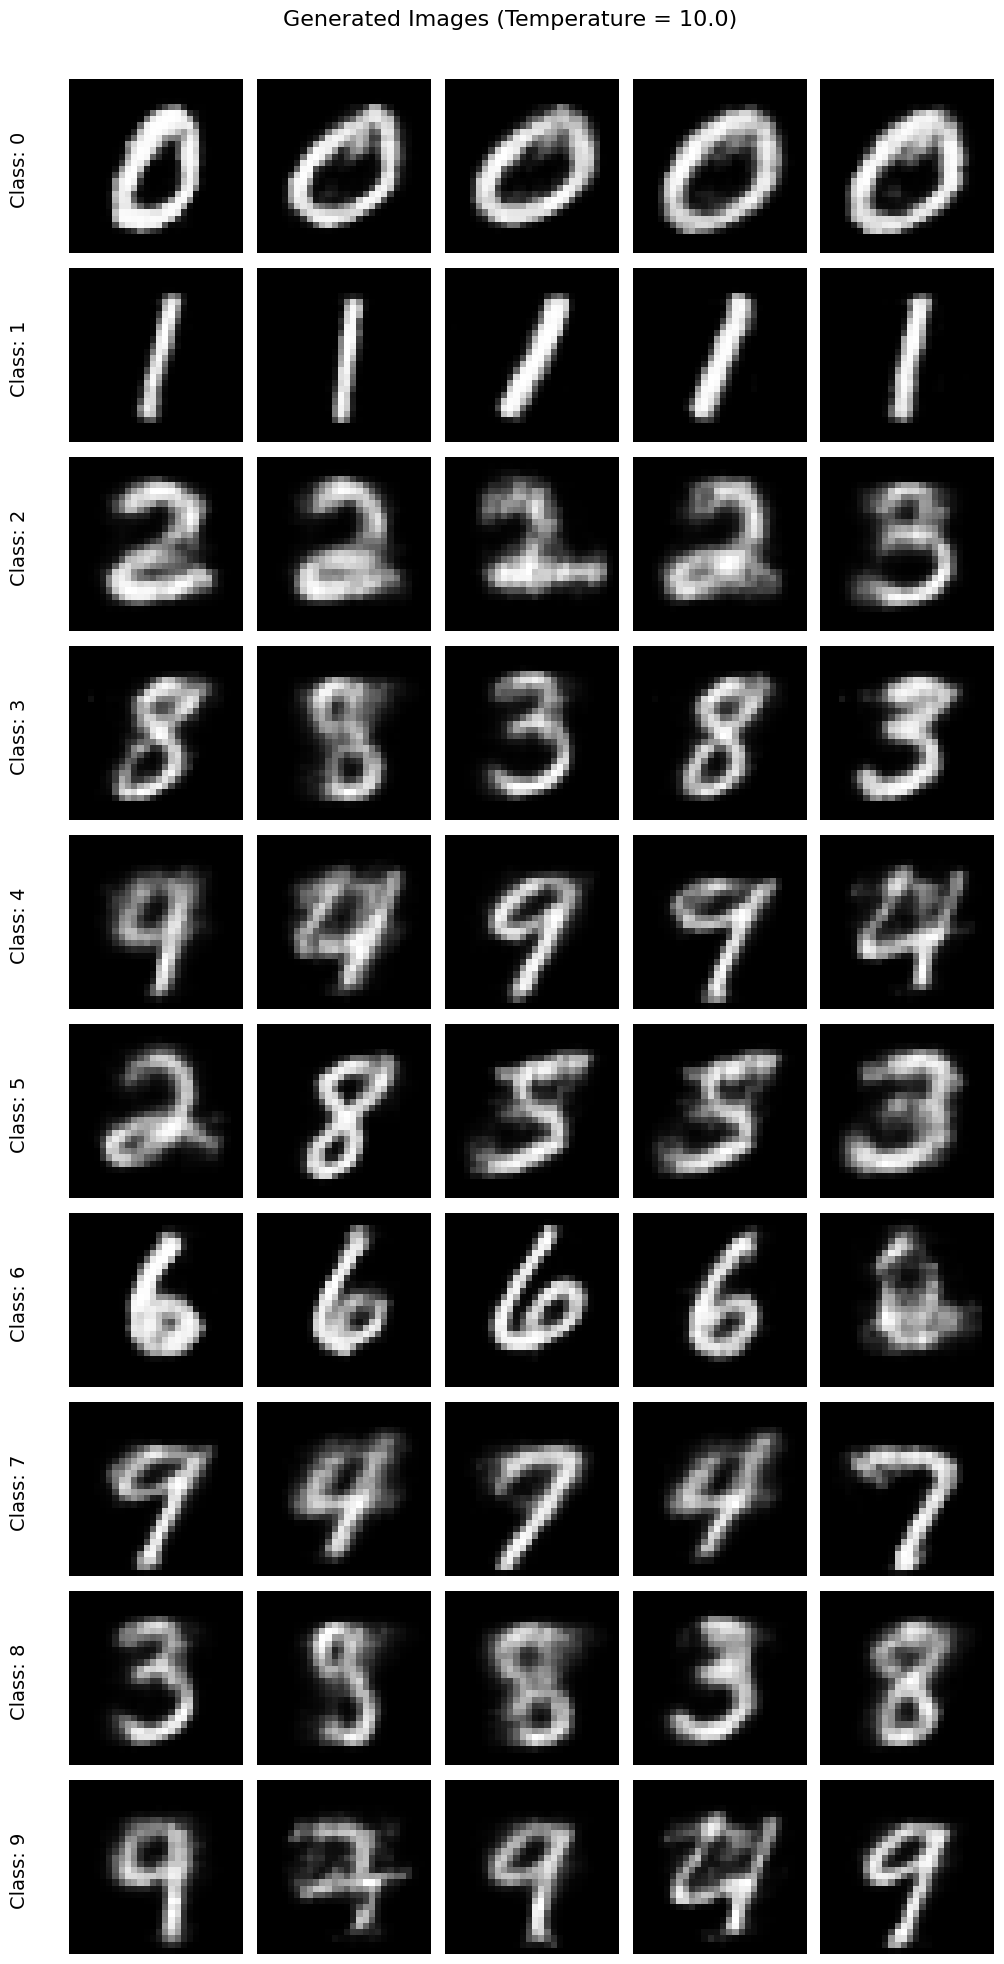

In [22]:
generate_and_plot_class_images(temperature=10.0)